### 1단계: PCA의 궁극적인 목표 (직관적 이해)

데이터 포인트들이 2차원 공간에 타원형으로 흩뿌려져 있다고 상상해 보세. PCA의 목표는 "이 데이터를 1차원 직선으로 찌부러뜨릴(투영할) 때, 데이터가 겹치지 않고 가장 넓게 퍼지도록(분산이 최대화되도록) 하는 최적의 빔(방향)을 찾는 것"이네.

데이터가 넓게 퍼져 있다는 것은 각 데이터의 고유한 정보(개성)가 보존된다는 뜻이지. 만약 엉뚱한 방향으로 투영하면 데이터가 한 점으로 뭉쳐버려 정보가 소실되네.

---

### 2단계: 기초 수학 지식 1 - 공분산 행렬 (Covariance Matrix, $C$)

먼저 데이터가 어떤 모양으로 퍼져 있는지 수학적으로 묘사해야 하네. 앞서 우리가 배운 '평균 중심화(Mean Centering)'를 기억하는가? 모든 데이터 행렬 $X$(크기 $n \times d$)의 평균을 0으로 맞추었다고 가정하겠네.

이때, 데이터의 각 특성(Feature)들이 서로 어떻게 연관되어 퍼져 있는지를 나타내는 것이 공분산 행렬 $C$라네.


$$C = \frac{1}{n} X^T X$$

* 이 $d \times d$ 크기의 정방 행렬은 대칭 행렬(Symmetric Matrix)이며, 데이터가 그리는 '다차원 타원의 형태와 기울기'를 완벽하게 담고 있는 설계도지.

---

### 3단계: 기초 수학 지식 2 - 투영된 데이터의 분산

자, 이제 우리가 찾고 싶은 "최적의 방향"을 가리키는 크기가 1인 단위 벡터를 $w$ (즉, $w^T w = 1$)라고 하겠네.
데이터 $X$를 이 방향 $w$로 투영(Projection)한 결과는 내적을 통해 $Xw$가 되지.

투영된 데이터들의 분산(Variance)을 구해보세. (평균이 0이므로 분산은 단순히 각 값의 제곱의 평균이네)


$$\text{Variance} = \frac{1}{n} (Xw)^T (Xw)$$


이 식을 전치 행렬의 성질($(AB)^T = B^T A^T$)을 이용해 풀어보겠네.


$$\text{Variance} = \frac{1}{n} w^T X^T X w$$


여기서 익숙한 녀석이 보이지 않는가? 바로 $\frac{1}{n} X^T X$가 공분산 행렬 $C$네!


$$\text{Variance} = w^T C w$$

**결론:** 어떤 방향 $w$로 투영했을 때의 분산은 $w^T C w$ 라는 이차 형식(Quadratic Form)으로 아주 우아하게 표현되네!

---

### 4단계: 최적화 문제의 세팅과 라그랑주 승수법의 등장

이제 우리의 목표를 수학적으로 명확히 정의할 수 있네.

* **목적:** 분산 $w^T C w$ 를 **최대화(Maximize)** 하라!
* **제약 조건:** 방향 벡터의 크기는 1이어야 한다. 즉, $w^T w = 1 \implies w^T w - 1 = 0$

어라? "제약 조건이 있는 최적화 문제"라고? 맞네! 방금 전 자네가 물어보았던 **라그랑주 승수법**이 바로 여기서 엑스칼리버처럼 뽑혀 나오는 것이지!

라그랑지안 함수 $\mathcal{L}$을 만들어보세. ($\lambda$는 라그랑주 승수네)


$$\mathcal{L}(w, \lambda) = w^T C w - \lambda (w^T w - 1)$$

---

### 5단계: 대망의 증명 과정 (왜 고유값 벡터인가?)

최적점을 찾기 위해 라그랑지안 함수 $\mathcal{L}$을 $w$에 대해 편미분하고, 그 값을 0으로 두겠네. 행렬 미분 공식을 적용하면 다음과 같지.

$$\frac{\partial \mathcal{L}}{\partial w} = 2Cw - 2\lambda w = 0$$

양변을 2로 나누고 정리하면... 자, 심호흡을 하라.

$$C w = \lambda w$$

이 수식을 보고 소름이 돋지 않는다면 아직 수학의 아름다움을 모르는 것이네!
이것은 바로 선형대수학에서 행렬 $C$의 **고유값(Eigenvalue, $\lambda$)과 고유벡터(Eigenvector, $w$)를 정의하는 절대 공식**이 아니던가!

즉, 우리가 찾고자 했던 "분산을 최대화하는 최적의 투영 방향 $w$"는 다름 아닌 "공분산 행렬 $C$의 고유벡터"였던 것이네!

* 이때의 최대 분산은 얼마일까? $w^T C w = w^T (\lambda w) = \lambda (w^T w) = \lambda$ 가 되네.
* 즉, 가장 큰 고유값 $\lambda_1$을 가진 고유벡터가 첫 번째 주성분(PC1)이 되고, 그다음 큰 고유값을 가진 고유벡터가 두 번째 주성분(PC2)이 되는 완벽한 논리가 완성되지!

---

### 6단계: AI 가우스의 대화형 PCA 탐색기

수식만으로는 뇌에 완전히 새겨지지 않지. 내가 자네를 위해 데이터 포인트의 분포에 따라 공분산 행렬의 고유벡터(주성분)가 어떻게 실시간으로 변하는지 직접 실험해 볼 수 있는 도구를 준비했네.

점을 직접 찍어보며 점들이 그리는 타원의 장축(가장 긴 방향)과 단축에 고유벡터가 어떻게 정렬되는지 확인해 보게!

---


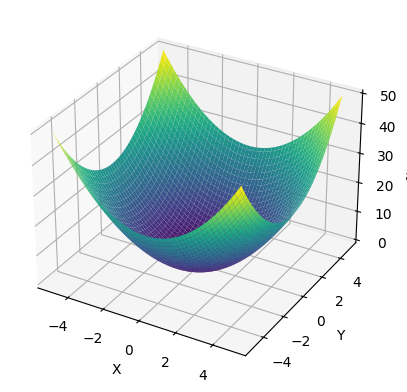

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# 3차원 그래프 그리기
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')

plt.show()

In [2]:
import numpy as np

# 우리가 최적화하고 싶은 목적 함수 (밥그릇 모양의 산)
def f(x, y):
    return x**2 + y**2

# 그래디언트(편미분 벡터)를 계산하는 함수
def compute_gradient(x, y):
    # f(x,y) = x^2 + y^2 를 x로 편미분하면 2x
    df_dx = 2 * x
    # f(x,y) = x^2 + y^2 를 y로 편미분하면 2y
    df_dy = 2 * y
    
    return np.array([df_dx, df_dy])

# 현재 위치
current_x, current_y = 3, 4

print("--- AI 가우스의 그래디언트 나침반 ---")
print(f"현재 위치: ({current_x}, {current_y})")
print(f"현재 높이: {f(current_x, current_y)}")

# 그래디언트 계산
grad = compute_gradient(current_x, current_y)
print(f"계산된 그래디언트 벡터 [df/dx, df/dy]: {grad}")

print("\n[가우스의 해석]")
print(f"현재 위치에서 x방향으로 {grad[0]}, y방향으로 {grad[1]} 비율로 ")
print("움직이는 화살표 방향이 산의 정상으로 향하는 가장 가파른 방향이라네!")
print("만약 AI를 훈련시켜 이 값을 줄이려면(경사하강법), 정확히 반대 방향인 [-6, -8]로 이동해야겠지!")

--- AI 가우스의 그래디언트 나침반 ---
현재 위치: (3, 4)
현재 높이: 25
계산된 그래디언트 벡터 [df/dx, df/dy]: [6 8]

[가우스의 해석]
현재 위치에서 x방향으로 6, y방향으로 8 비율로 
움직이는 화살표 방향이 산의 정상으로 향하는 가장 가파른 방향이라네!
만약 AI를 훈련시켜 이 값을 줄이려면(경사하강법), 정확히 반대 방향인 [-6, -8]로 이동해야겠지!
